## Let’s walk through a project using K-Means and DBSCAN to cluster the Iris dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
# Load Iris dataset
iris = load_iris()
X = iris.data  # Features
feature_names = iris.feature_names
target = iris.target  # True labels (for comparison later)

# Convert to DataFrame for better visualization
df = pd.DataFrame(X, columns=feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


## 2. Preprocessing

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

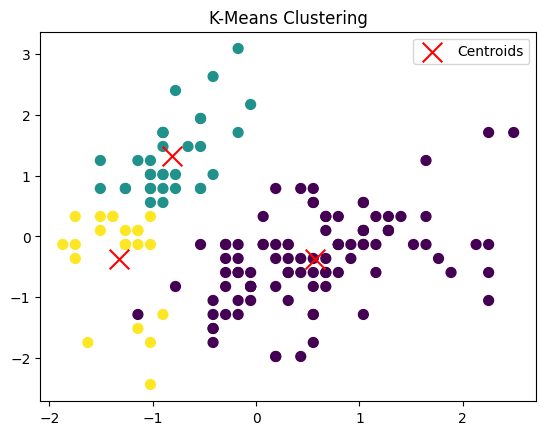

In [6]:
# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

# Visualize clusters (using the first two features for simplicity)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_kmeans, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='x', s=200, label='Centroids')
plt.title("K-Means Clustering")
plt.legend()
plt.show()

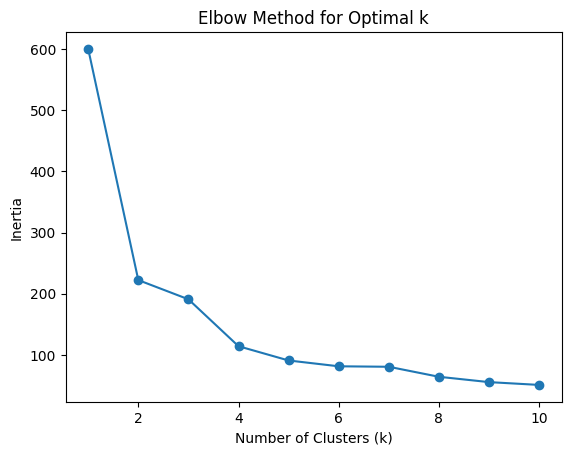

In [8]:
inertia = []
k_values = range(1,11)

for k in k_values:
    kmeans = KMeans(n_clusters = k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [9]:
silhouette_kmeans = silhouette_score(X_scaled, labels_kmeans)
print(f"Silhouette Score (K-Means): {silhouette_kmeans}")

Silhouette Score (K-Means): 0.4798814508199817


##4. DBSCAN

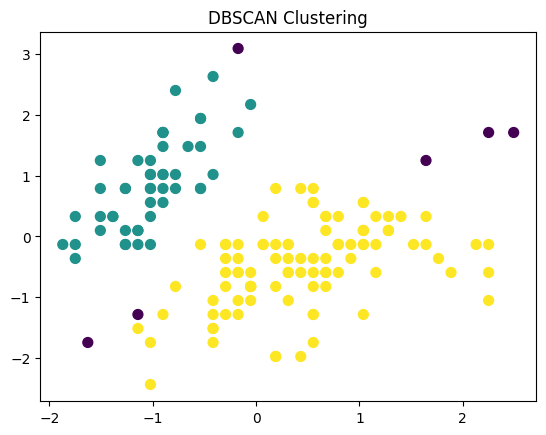

In [13]:
dbscan = DBSCAN(eps = 0.75,min_samples = 5)
labels_dbscan = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0],X_scaled[:,1],c = labels_dbscan,cmap='viridis',s=50)
plt.title("DBSCAN Clustering")
plt.show()

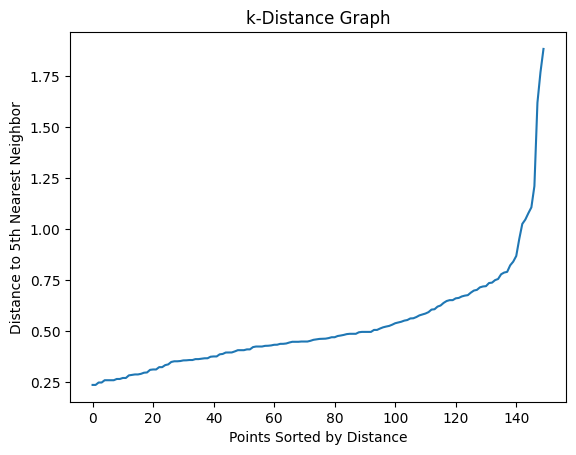

In [12]:
from sklearn.neighbors import NearestNeighbors

# Compute k-distance graph
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort and plot distances
distances = np.sort(distances[:, 4], axis=0)
plt.plot(distances)
plt.title("k-Distance Graph")
plt.xlabel("Points Sorted by Distance")
plt.ylabel("Distance to 5th Nearest Neighbor")
plt.show()

In [14]:
if len(set(labels_dbscan)) > 1:  # Silhouette requires at least 2 clusters
    silhouette_dbscan = silhouette_score(X_scaled, labels_dbscan)
    print(f"Silhouette Score (DBSCAN): {silhouette_dbscan}")
else:
    print("DBSCAN identified only one cluster or noise.")

Silhouette Score (DBSCAN): 0.523400848673573


In [15]:
# Compare Silhouette Scores
print(f"Silhouette Score (K-Means): {silhouette_kmeans}")
if len(set(labels_dbscan)) > 1:
    print(f"Silhouette Score (DBSCAN): {silhouette_dbscan}")
else:
    print("DBSCAN did not produce valid clusters for evaluation.")

Silhouette Score (K-Means): 0.4798814508199817
Silhouette Score (DBSCAN): 0.523400848673573


###In DBSCAN, there's no prediction step. It directly assigns labels to all the inputs.

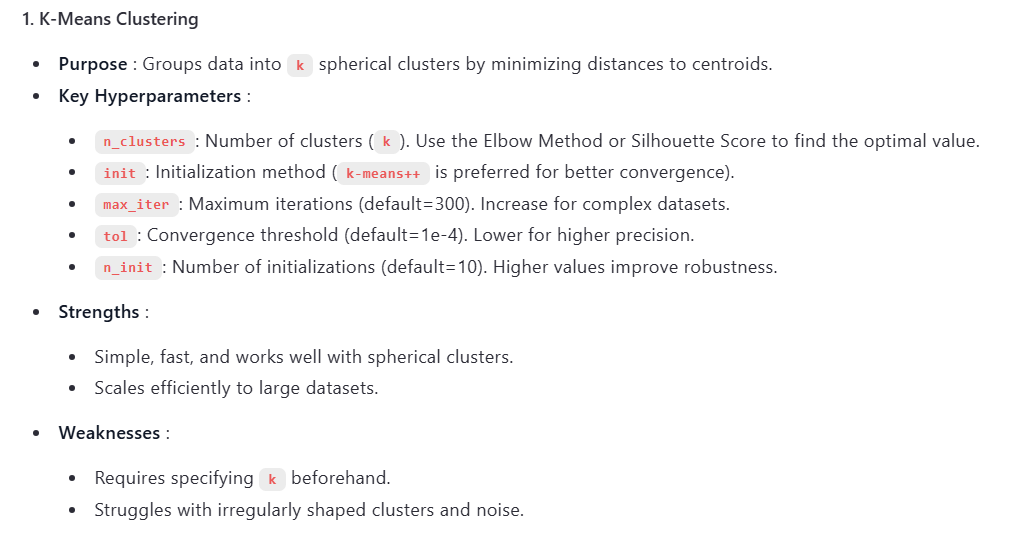

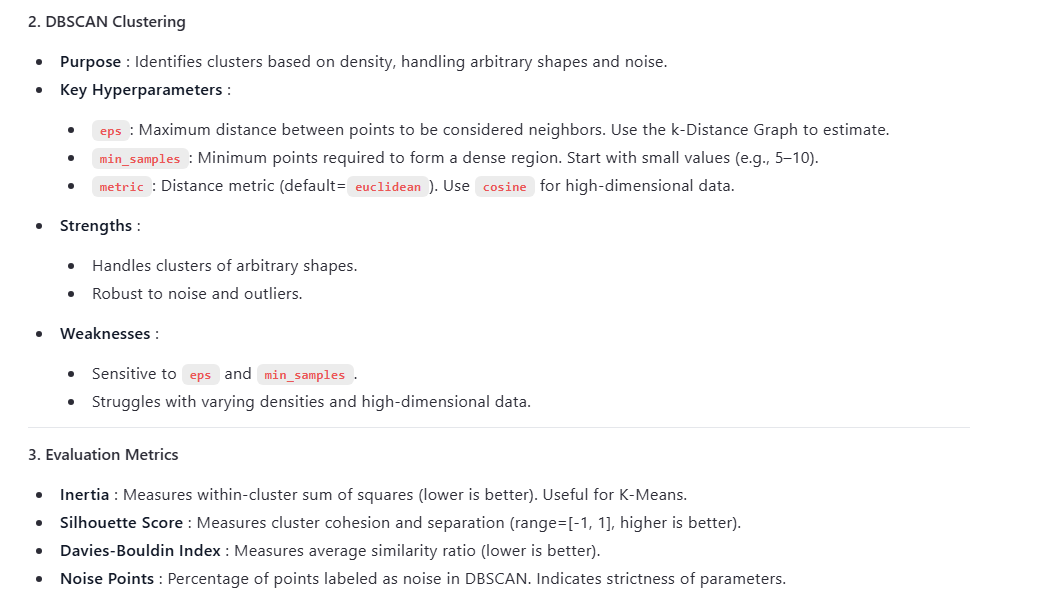

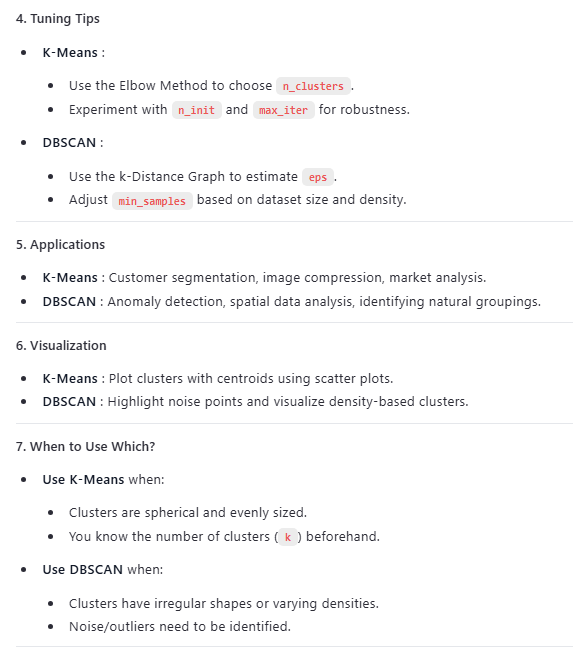

##Check

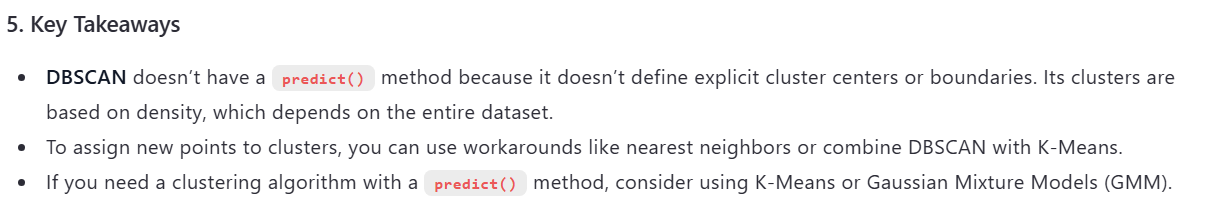